# NLP Disaster Tweets — Классические методы NLP

Альтернативный подход к задаче бинарной классификации твитов.  
Сравниваем три метода:

| Метод | Представление текста | Классификатор |
|-------|---------------------|---------------|
| Bag of Words | CountVectorizer (частоты слов) | Logistic Regression |
| TF-IDF | TfidfVectorizer (взвешенные частоты) | Logistic Regression + SVM |
| Word2Vec | Усреднённые word embeddings | Logistic Regression |

Метрика: **F1-score** (как в соревновании Kaggle).

## 1. Импорты и настройки

In [7]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag, word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

from gensim.models import Word2Vec

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

SEED = 42
np.random.seed(SEED)

print('Все библиотеки загружены')

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/e.loshmanov/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/e.loshmanov/nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     /home/e.loshmanov/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/e.loshmanov/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/e.loshmanov/nltk_data...


Все библиотеки загружены


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/e.loshmanov/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## 2. Загрузка данных

In [8]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

print(f'Train: {df_train.shape},  Test: {df_test.shape}')
df_train.head()

Train: (7613, 5),  Test: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


## 3. Анализ качества данных

In [9]:
# Дубликаты в train
dup_mask = df_train.duplicated('text', keep=False)
print(f'Строк с дублирующимся текстом: {dup_mask.sum()}')

# Конфликтующие метки — один твит размечен и как 0, и как 1
label_counts = df_train.groupby('text')['target'].nunique()
conflicting_texts = label_counts[label_counts > 1].index
print(f'Твитов с конфликтующими метками: {len(conflicting_texts)}')

# Пересечение train и test
test_texts = set(df_test['text'])
train_texts = set(df_train['text'])
overlap_texts = train_texts & test_texts
print(f'Одинаковых текстов в train и test: {len(overlap_texts)}')

print()
print('Пример конфликта:')
example = conflicting_texts[0]
print(df_train[df_train['text'] == example][['text', 'target']])

Строк с дублирующимся текстом: 179
Твитов с конфликтующими метками: 18
Одинаковых текстов в train и test: 68

Пример конфликта:
                                                   text  target
4290  #Allah describes piling up #wealth thinking it...       0
4299  #Allah describes piling up #wealth thinking it...       0
4312  #Allah describes piling up #wealth thinking it...       1


## 4. Дедупликация и разрешение конфликтов

- **Конфликтующие метки** — берём мажоритарный голос; при ничьей → 1 (лучше не пропустить катастрофу)
- **Чистые дубликаты** — удаляем, оставляем одну строку
- **Train/test overlap** — сохраняем метки из train; при предсказании на тесте подставим их напрямую

In [10]:
# Разрешаем конфликты мажоритарным голосом
def majority_label(labels):
    counts = labels.value_counts()
    if len(counts) > 1 and counts.iloc[0] == counts.iloc[1]:  # ничья → 1
        return 1
    return counts.idxmax()

resolved = df_train.groupby('text', sort=False)['target'].agg(majority_label).reset_index()
resolved.columns = ['text', 'target']

# Добавляем обратно keyword/location (берём первое вхождение)
first_meta = df_train.groupby('text', sort=False)[['keyword', 'location']].first().reset_index()
df_train_clean = resolved.merge(first_meta, on='text')

print(f'Train до очистки:  {len(df_train)} строк')
print(f'Train после очистки: {len(df_train_clean)} строк')
print(f'Удалено: {len(df_train) - len(df_train_clean)} строк')

# Словарь text → label для overlap-твитов (известные ответы)
overlap_labels = (
    df_train_clean[df_train_clean['text'].isin(overlap_texts)]
    .set_index('text')['target']
    .to_dict()
)
print(f'\nЗнаем метки для {len(overlap_labels)} тестовых твитов из train')

Train до очистки:  7613 строк
Train после очистки: 7503 строк
Удалено: 110 строк

Знаем метки для 68 тестовых твитов из train


## 5. Очистка текста и лемматизация

**Лемматизация** — приведение слова к базовой форме с учётом части речи:  
`fires → fire`, `running → run`, `better → good`.  
Это уменьшает словарь и помогает TF-IDF/BoW объединять однокоренные слова.

In [11]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag: str) -> str:
    """Конвертирует POS-тег Penn Treebank в формат WordNet."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

def clean_text(text: str) -> str:
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'[^\w\s.,!?\'-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

def lemmatize_text(text: str) -> str:
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    return ' '.join(
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
    )

def preprocess(text: str) -> str:
    return lemmatize_text(clean_text(text))

print('Применяем препроцессинг...')
df_train_clean['clean_text'] = df_train_clean['text'].apply(preprocess)
df_test['clean_text']        = df_test['text'].apply(preprocess)

print('Готово. Примеры:')
for orig, proc in zip(df_train_clean['text'][:3], df_train_clean['clean_text'][:3]):
    print(f'  ORIG : {orig}')
    print(f'  PROC : {proc}')
    print()

Применяем препроцессинг...
Готово. Примеры:
  ORIG : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
  PROC : our deed be the reason of this earthquake may allah forgive u all

  ORIG : Forest fire near La Ronge Sask. Canada
  PROC : forest fire near la ronge sask . canada

  ORIG : All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected
  PROC : all resident ask to 'shelter in place ' be be notify by officer . no other evacuation or shelter in place order be expect



## 6. Train/Val split

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    df_train_clean['clean_text'], df_train_clean['target'],
    test_size=0.15, random_state=SEED, stratify=df_train_clean['target']
)

print(f'Train: {len(X_train)}, Val: {len(X_val)}')
print(f'Распределение классов в train: {y_train.value_counts().to_dict()}')

Train: 6377, Val: 1126
Распределение классов в train: {0: 3656, 1: 2721}


## 7. Подход 1 — Bag of Words + Logistic Regression

**Bag of Words** — каждый твит представляется вектором длиной = размер словаря.  
Значение i-го элемента = количество вхождений i-го слова в текст.  
Порядок слов и контекст полностью игнорируются.

In [13]:
bow_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        stop_words='english'
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        C=1.0
    ))
])

bow_pipeline.fit(X_train, y_train)
bow_val_preds = bow_pipeline.predict(X_val)
bow_f1 = f1_score(y_val, bow_val_preds)

print(f'BoW + LogReg | Val F1: {bow_f1:.4f}')
print()
print(classification_report(y_val, bow_val_preds, target_names=['Not Disaster', 'Disaster']))

BoW + LogReg | Val F1: 0.7367

              precision    recall  f1-score   support

Not Disaster       0.79      0.86      0.82       646
    Disaster       0.79      0.69      0.74       480

    accuracy                           0.79      1126
   macro avg       0.79      0.78      0.78      1126
weighted avg       0.79      0.79      0.79      1126



## 8. Подход 2 — TF-IDF + Logistic Regression и SVM

**TF-IDF** (Term Frequency–Inverse Document Frequency) — улучшение BoW.  
Слова, которые встречаются во многих документах (например, "the"), получают меньший вес.  
Редкие, но важные слова — больший вес.

In [14]:
tfidf_lr_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        stop_words='english'
    )),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=SEED,
        C=5.0
    ))
])

tfidf_svm_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
        stop_words='english'
    )),
    ('classifier', LinearSVC(
        max_iter=2000,
        random_state=SEED,
        C=1.0
    ))
])

tfidf_lr_pipeline.fit(X_train, y_train)
tfidf_svm_pipeline.fit(X_train, y_train)

tfidf_lr_preds  = tfidf_lr_pipeline.predict(X_val)
tfidf_svm_preds = tfidf_svm_pipeline.predict(X_val)

tfidf_lr_f1  = f1_score(y_val, tfidf_lr_preds)
tfidf_svm_f1 = f1_score(y_val, tfidf_svm_preds)

print(f'TF-IDF + LogReg | Val F1: {tfidf_lr_f1:.4f}')
print(f'TF-IDF + SVM    | Val F1: {tfidf_svm_f1:.4f}')
print()
print('--- TF-IDF + SVM ---')
print(classification_report(y_val, tfidf_svm_preds, target_names=['Not Disaster', 'Disaster']))

TF-IDF + LogReg | Val F1: 0.7462
TF-IDF + SVM    | Val F1: 0.7300

--- TF-IDF + SVM ---
              precision    recall  f1-score   support

Not Disaster       0.79      0.82      0.81       646
    Disaster       0.75      0.71      0.73       480

    accuracy                           0.78      1126
   macro avg       0.77      0.77      0.77      1126
weighted avg       0.77      0.78      0.77      1126



### Самые важные признаки TF-IDF

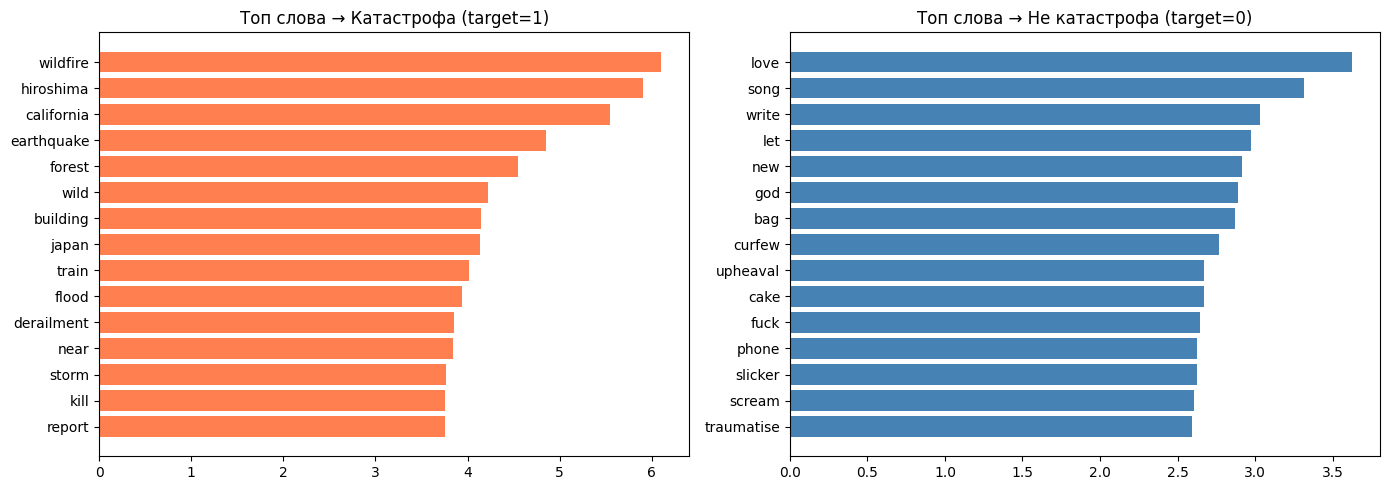

In [15]:
vectorizer    = tfidf_lr_pipeline.named_steps['vectorizer']
clf           = tfidf_lr_pipeline.named_steps['classifier']
feature_names = vectorizer.get_feature_names_out()

top_n = 15
coef  = clf.coef_[0]

top_disaster     = [(feature_names[i], coef[i]) for i in coef.argsort()[-top_n:][::-1]]
top_not_disaster = [(feature_names[i], coef[i]) for i in coef.argsort()[:top_n]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

words, scores = zip(*top_disaster)
axes[0].barh(words, scores, color='coral')
axes[0].set_title('Топ слова → Катастрофа (target=1)')
axes[0].invert_yaxis()

words, scores = zip(*top_not_disaster)
axes[1].barh(words, np.abs(scores), color='steelblue')
axes[1].set_title('Топ слова → Не катастрофа (target=0)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Подход 3 — Word2Vec + Logistic Regression

**Word2Vec** — нейросетевой метод получения плотных векторных представлений слов (embeddings).  
Слова со схожим контекстом → близкие векторы в пространстве.  
Например: `king - man + woman ≈ queen`.

Твит представляем как **среднее векторов** всех его слов.

In [16]:
def tokenize(text: str) -> list:
    # Оставляем только буквенно-цифровые токены — пунктуацию из word_tokenize отбрасываем
    return [t for t in text.split() if re.match(r'^\w+$', t)]

train_tokens = X_train.apply(tokenize).tolist()
val_tokens   = X_val.apply(tokenize).tolist()
test_tokens  = df_test['clean_text'].apply(tokenize).tolist()

all_tokens = train_tokens + val_tokens + test_tokens

w2v_model = Word2Vec(
    sentences=all_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=SEED,
    epochs=10
)

print(f'Словарь Word2Vec: {len(w2v_model.wv)} слов')
print('\nБлижайшие к "fire":', w2v_model.wv.most_similar('fire', topn=5))
print('Ближайшие к "flood":', w2v_model.wv.most_similar('flood', topn=5))

Словарь Word2Vec: 6761 слов

Ближайшие к "fire": [('wild', 0.8597451448440552), ('forest', 0.851837158203125), ('building', 0.8416502475738525), ('rocky', 0.7965388298034668), ('catch', 0.7621198296546936)]
Ближайшие к "flood": [('combo', 0.9770575165748596), ('53inch', 0.9755193591117859), ('flash', 0.9712275266647339), ('madhya', 0.9690645933151245), ('pradesh', 0.9687384366989136)]


In [17]:
def texts_to_vectors(token_lists, model):
    vectors = []
    for tokens in token_lists:
        valid = [model.wv[w] for w in tokens if w in model.wv]
        if valid:
            vectors.append(np.mean(valid, axis=0))
        else:
            vectors.append(np.zeros(model.vector_size))
    return np.array(vectors)

X_train_w2v = texts_to_vectors(train_tokens, w2v_model)
X_val_w2v   = texts_to_vectors(val_tokens,   w2v_model)
X_test_w2v  = texts_to_vectors(test_tokens,  w2v_model)

print(f'Train матрица: {X_train_w2v.shape}')
print(f'Val матрица:   {X_val_w2v.shape}')

Train матрица: (6377, 100)
Val матрица:   (1126, 100)


In [18]:
w2v_clf = LogisticRegression(max_iter=1000, random_state=SEED, C=5.0)
w2v_clf.fit(X_train_w2v, y_train)

w2v_preds = w2v_clf.predict(X_val_w2v)
w2v_f1    = f1_score(y_val, w2v_preds)

print(f'Word2Vec + LogReg | Val F1: {w2v_f1:.4f}')
print()
print(classification_report(y_val, w2v_preds, target_names=['Not Disaster', 'Disaster']))

Word2Vec + LogReg | Val F1: 0.6777

              precision    recall  f1-score   support

Not Disaster       0.75      0.82      0.78       646
    Disaster       0.72      0.64      0.68       480

    accuracy                           0.74      1126
   macro avg       0.74      0.73      0.73      1126
weighted avg       0.74      0.74      0.74      1126



## 10. Сравнение всех методов

            Метод   Val F1
DistilBERT (ref.) 0.814100
  TF-IDF + LogReg 0.746204
     BoW + LogReg 0.736726
     TF-IDF + SVM 0.729989
Word2Vec + LogReg 0.677704


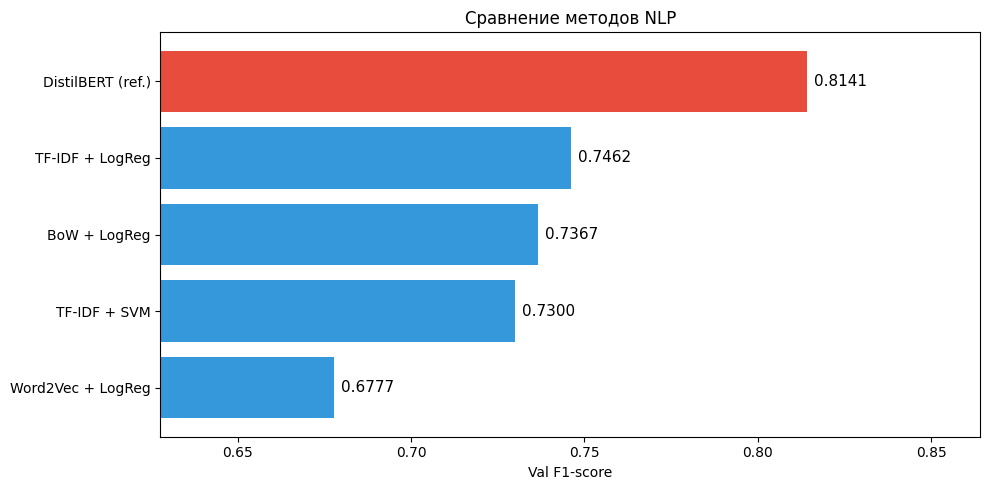

In [19]:
results = {
    'BoW + LogReg':       bow_f1,
    'TF-IDF + LogReg':    tfidf_lr_f1,
    'TF-IDF + SVM':       tfidf_svm_f1,
    'Word2Vec + LogReg':  w2v_f1,
    'DistilBERT (ref.)':  0.8141,
}

results_df = pd.DataFrame(list(results.items()), columns=['Метод', 'Val F1'])
results_df = results_df.sort_values('Val F1', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if 'DistilBERT' in m else '#3498db' for m in results_df['Метод']]
bars = ax.barh(results_df['Метод'], results_df['Val F1'], color=colors)

min_val = results_df['Val F1'].min()
max_val = results_df['Val F1'].max()
ax.set_xlim(max(0.0, min_val - 0.05), min(1.0, max_val + 0.05))
ax.set_xlabel('Val F1-score')
ax.set_title('Сравнение методов NLP')
ax.invert_yaxis()

for bar, val in zip(bars, results_df['Val F1']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

## 11. Confusion Matrix лучшей классической модели

Лучшая классическая модель: TF-IDF + LogReg | Val F1: 0.7462


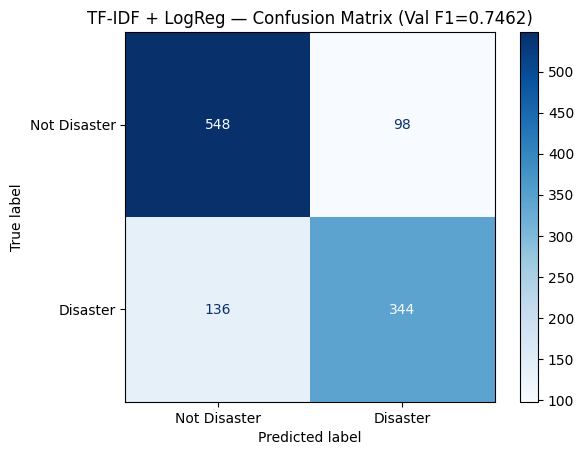

In [20]:
classical_results = {
    'BoW + LogReg':      (bow_pipeline,       bow_val_preds),
    'TF-IDF + LogReg':   (tfidf_lr_pipeline,  tfidf_lr_preds),
    'TF-IDF + SVM':      (tfidf_svm_pipeline, tfidf_svm_preds),
    'Word2Vec + LogReg': (w2v_clf,             w2v_preds),
}

best_name  = max(classical_results, key=lambda k: f1_score(y_val, classical_results[k][1]))
best_preds = classical_results[best_name][1]
best_f1    = f1_score(y_val, best_preds)

print(f'Лучшая классическая модель: {best_name} | Val F1: {best_f1:.4f}')

cm = confusion_matrix(y_val, best_preds)
ConfusionMatrixDisplay(cm, display_labels=['Not Disaster', 'Disaster']).plot(cmap='Blues')
plt.title(f'{best_name} — Confusion Matrix (Val F1={best_f1:.4f})')
plt.show()

## 12. Submission с использованием train/test overlap

Для 68 твитов, которые есть и в train, и в test, метки уже известны — подставляем напрямую вместо предсказания модели.

In [21]:
# Предсказания лучшей модели на всём тест-сете
if best_name == 'Word2Vec + LogReg':
    test_preds = w2v_clf.predict(X_test_w2v).tolist()
else:
    pipeline_map = {
        'BoW + LogReg':    bow_pipeline,
        'TF-IDF + LogReg': tfidf_lr_pipeline,
        'TF-IDF + SVM':    tfidf_svm_pipeline,
    }
    test_preds = pipeline_map[best_name].predict(df_test['clean_text']).tolist()

# Перезаписываем известные метки из train
overridden = 0
for i, text in enumerate(df_test['text']):
    if text in overlap_labels:
        test_preds[i] = overlap_labels[text]
        overridden += 1

print(f'Перезаписано предсказаний из train/test overlap: {overridden}')

submission = pd.read_csv('data/sample_submission.csv')
submission['target'] = test_preds
submission.to_csv('submission_classical.csv', index=False)

print(f'submission_classical.csv сохранён ({best_name} + overlap fix)')
print(f'Disaster: {sum(test_preds)}, Not disaster: {len(test_preds) - sum(test_preds)}')
submission.head()

Перезаписано предсказаний из train/test overlap: 78
submission_classical.csv сохранён (TF-IDF + LogReg + overlap fix)
Disaster: 1250, Not disaster: 2013


,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1
